### 0. Imports and Paths

In [2]:
# import packages
import random
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xml.etree.ElementTree as ET
from PIL import Image
import matplotlib.patches as patches

In [3]:
# define paths
DATA_ROOT = Path("../data")

IMAGES_DIR = DATA_ROOT / "images"
LABELS_DIR = DATA_ROOT / "labels"
VOC_DIR = DATA_ROOT / "voc_labels"

TRAIN_FILE = DATA_ROOT / "train_files.txt"
VAL_FILE = DATA_ROOT / "val_files.txt"

### 1. Data Integrity & Image counts

In [4]:
# load train and val file lists
with open(TRAIN_FILE) as f:
    train_files = [line.strip() for line in f]

with open(VAL_FILE) as f:
    val_files = [line.strip() for line in f]

used_images = set(train_files + val_files)
all_images = {p.name for p in IMAGES_DIR.glob("*")}

# print summary
print(f"Images on disk: {len(all_images)}")
print(f"Images in train+val: {len(used_images)}")
print(f"Unused images: {len(all_images - used_images)}")

print(f"Train images: {len(train_files)} ({len(train_files)/len(all_images)*100:.1f}%)")
print(f"Val images: {len(val_files)} ({len(val_files)/len(all_images)*100:.1f}%)")
print(f"Train/Val overlap: {len(set(train_files) & set(val_files))}")

Images on disk: 8099
Images in train+val: 8099
Unused images: 8099
Train images: 6479 (80.0%)
Val images: 1620 (20.0%)
Train/Val overlap: 0


### 2. Image distributions

In [5]:
# analyze image dimensions and aspect ratios
image_records = []

for xml_file in VOC_DIR.glob("*.xml"):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    filename = root.find("filename").text
    size = root.find("size")

    w = int(size.find("width").text)
    h = int(size.find("height").text)

    image_records.append({"image": filename, "width": w, "height": h, "aspect_ratio": w / h})

img_df = pd.DataFrame(image_records)

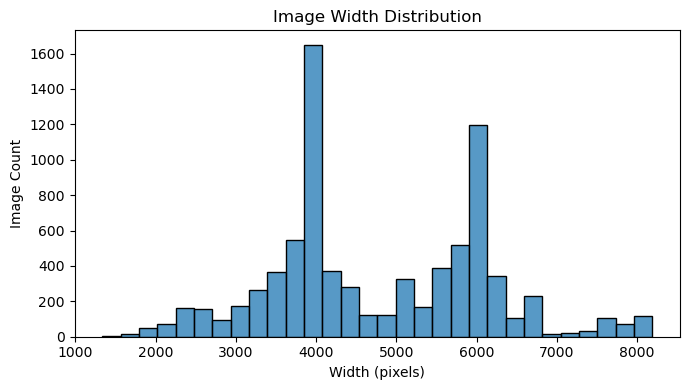

In [6]:
# plot image width distribution
plt.figure(figsize=(7, 4))
sns.histplot(img_df["width"], bins=30)
plt.title("Image Width Distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Image Count")
plt.tight_layout()
plt.show()

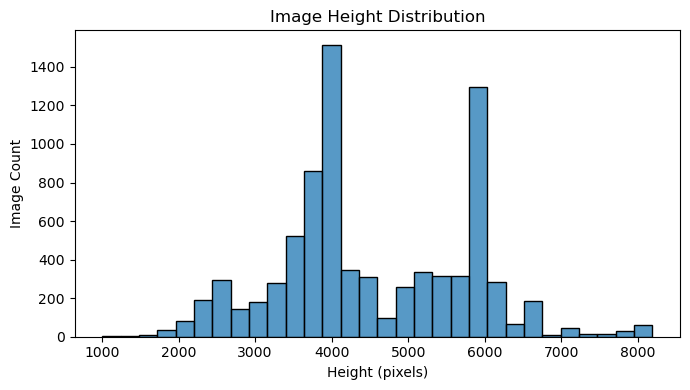

In [7]:
# plot image height distribution
plt.figure(figsize=(7, 4))
sns.histplot(img_df["height"], bins=30)
plt.title("Image Height Distribution")
plt.xlabel("Height (pixels)")
plt.ylabel("Image Count")
plt.tight_layout()
plt.show()

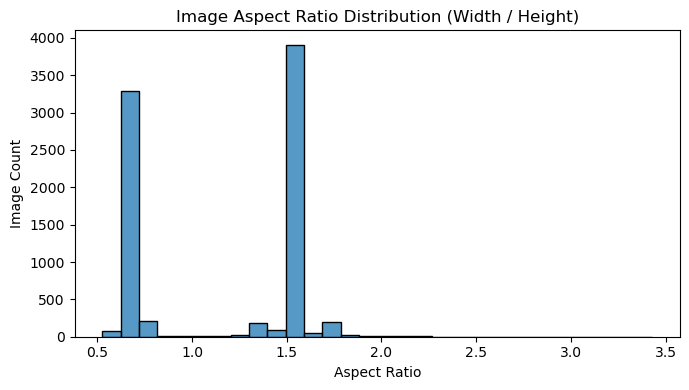

In [8]:
# plot aspect ratio distribution
plt.figure(figsize=(7, 4))
sns.histplot(img_df["aspect_ratio"], bins=30)
plt.title("Image Aspect Ratio Distribution (Width / Height)")
plt.xlabel("Aspect Ratio")
plt.ylabel("Image Count")
plt.tight_layout()
plt.show()

### 2. Parse VOC Annotations

In [9]:
# analyze bounding box sizes and areas
records = []

for xml_file in VOC_DIR.glob("*.xml"):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    filename = root.find("filename").text

    size = root.find("size")
    img_w = int(size.find("width").text)
    img_h = int(size.find("height").text)

    for obj in root.findall("object"):
        name = obj.find("name").text
        bbox = obj.find("bndbox")

        xmin = int(bbox.find("xmin").text)
        xmax = int(bbox.find("xmax").text)
        ymin = int(bbox.find("ymin").text)
        ymax = int(bbox.find("ymax").text)

        box_w = xmax - xmin
        box_h = ymax - ymin
        area = box_w * box_h

        records.append({
            "image": filename,
            "class": name,
            "box_width": box_w,
            "box_height": box_h,
            "box_area": area,
            "img_width": img_w,
            "img_height": img_h,
            "area_norm": area / (img_w * img_h)
        })

df = pd.DataFrame(records)
df.head()

,image,class,box_width,box_height,box_area,img_width,img_height,area_norm
0,building-construction-building-site-constructi...,gloves,1275,1517,1934175,5760,3840,0.087446
1,career-firefighter-relaxing-job-162540.jpeg,hands,427,876,374052,6000,4000,0.015586
2,career-firefighter-relaxing-job-162540.jpeg,shoes,1398,1459,2039682,6000,4000,0.084987
3,career-firefighter-relaxing-job-162540.jpeg,safety-suit,2935,1421,4170635,6000,4000,0.173776
4,career-firefighter-relaxing-job-162540.jpeg,helmet,1499,1099,1647401,6000,4000,0.068642


### 3. Class Distribution

#### 3.1. Instances per Class

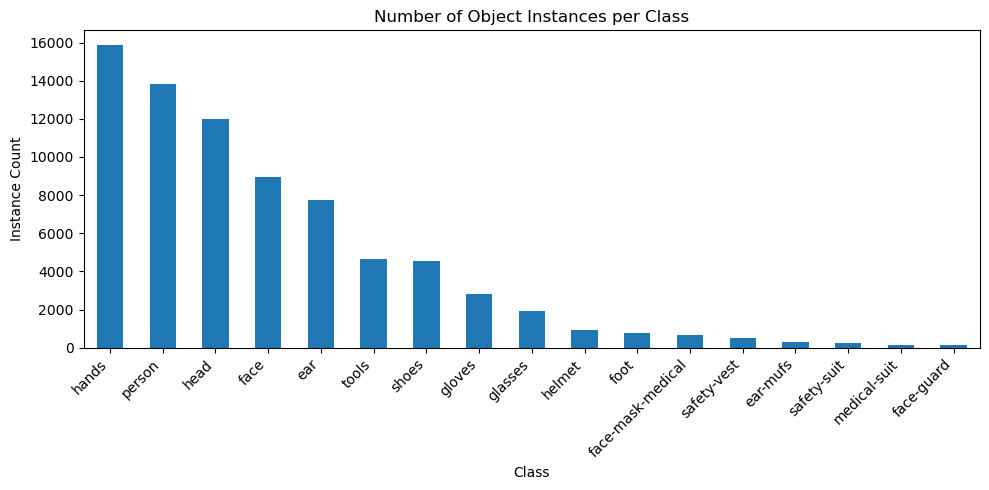

In [10]:
# plot class distribution
class_counts = df["class"].value_counts()

plt.figure(figsize=(10, 5))
class_counts.plot(kind="bar")
plt.title("Number of Object Instances per Class")
plt.ylabel("Instance Count")
plt.xlabel("Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

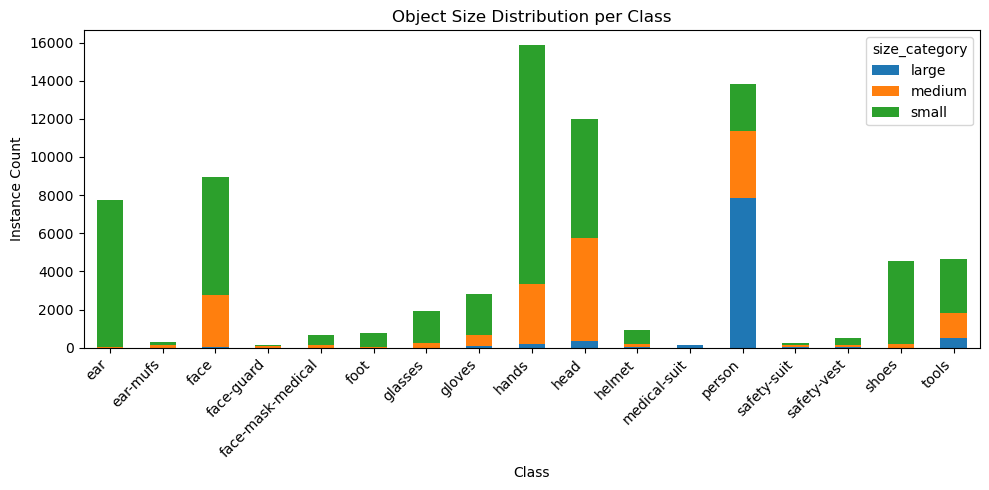

In [11]:
def size_category(a):
    if a < 0.02:
        return "small"
    elif a < 0.15:
        return "medium"
    return "large"

df["size_category"] = df["area_norm"].apply(size_category)

size_dist = (df.groupby(["class", "size_category"]).size().unstack(fill_value=0))

size_dist.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("Object Size Distribution per Class")
plt.ylabel("Instance Count")
plt.xlabel("Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### 3.2. Images Containing Each Class

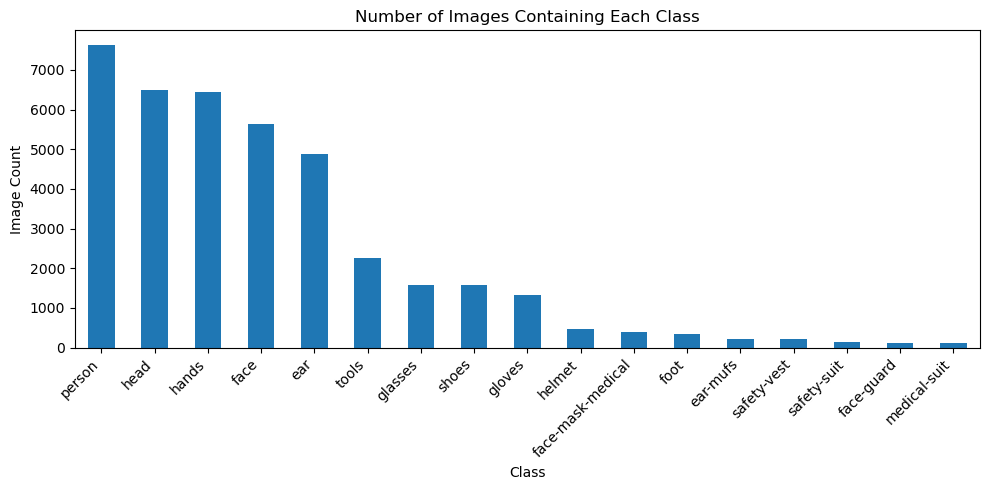

In [12]:
# plot number of images containing each class
images_per_class = (df.groupby("class")["image"].nunique().sort_values(ascending=False))

plt.figure(figsize=(10, 5))
images_per_class.plot(kind="bar")
plt.title("Number of Images Containing Each Class")
plt.ylabel("Image Count")
plt.xlabel("Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### 3.3. Objects per Image

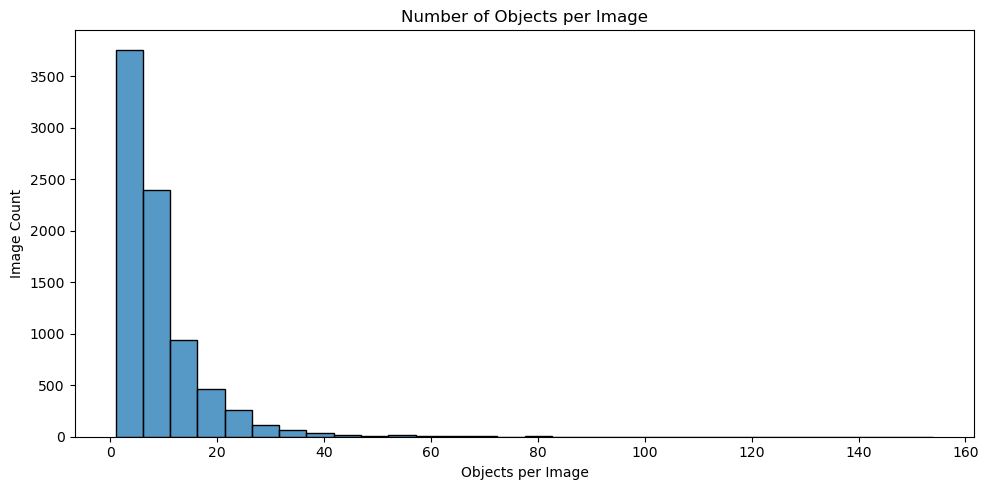

In [13]:
# plot number of objects per image
objects_per_image = df.groupby("image").size()

plt.figure(figsize=(10, 5))
sns.histplot(objects_per_image, bins=30)
plt.title("Number of Objects per Image")
plt.xlabel("Objects per Image")
plt.ylabel("Image Count")
plt.tight_layout()
plt.show()

### 4. Bounding Box Size Distribution

#### 4.1 With outliers

C:\Users\Linde Huijben\AppData\Local\Temp\ipykernel_20068\2238291850.py:3: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df, x="class", y="area_norm", scale="width", inner="quartile")


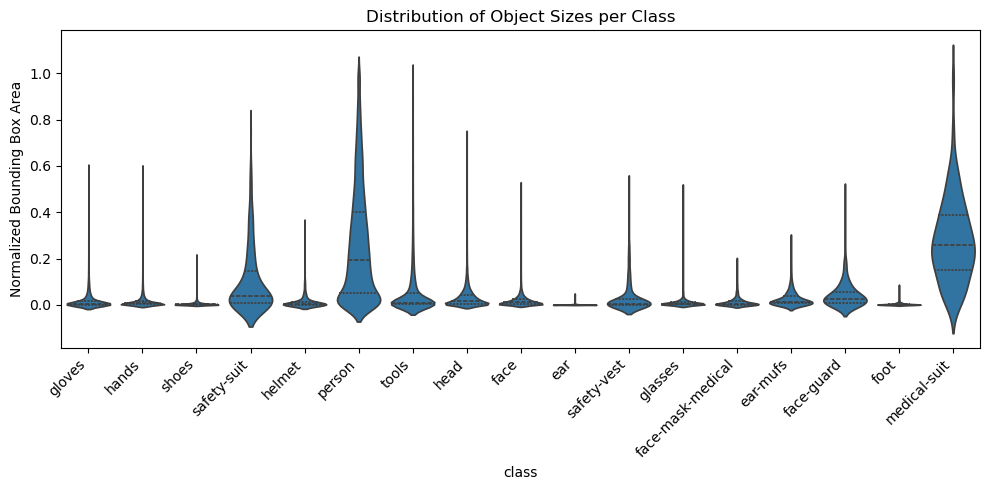

In [16]:
# plot distribution of normalized bounding box areas per class
plt.figure(figsize=(10, 5))
sns.violinplot(data=df, x="class", y="area_norm", scale="width", inner="quartile")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Normalized Bounding Box Area")
plt.title("Distribution of Object Sizes per Class")
plt.tight_layout()
plt.show()

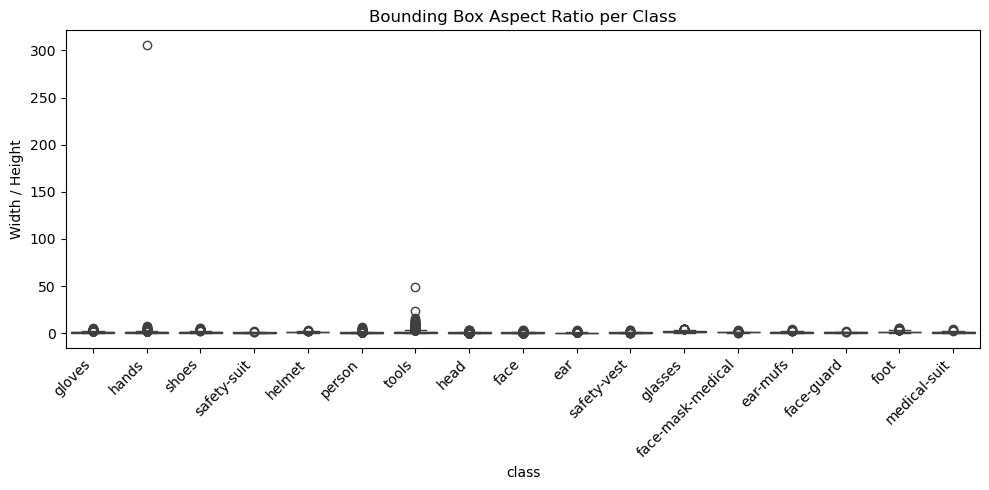

In [17]:
# plot aspect ratio distribution per class
df["aspect_ratio"] = df["box_width"] / df["box_height"]

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="class", y="aspect_ratio")
plt.xticks(rotation=45, ha="right")
plt.title("Bounding Box Aspect Ratio per Class")
plt.ylabel("Width / Height")
plt.tight_layout()
plt.show()

#### 4.2. Without Outliers

In [18]:
# Remove outliers per class using IQR
filtered_dfs = []

for cls, g in df.groupby("class"):
    q1 = g["aspect_ratio"].quantile(0.25)
    q3 = g["aspect_ratio"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    filtered_dfs.append(g[(g["aspect_ratio"] >= lower) & (g["aspect_ratio"] <= upper)])

df_no_outliers = pd.concat(filtered_dfs)

C:\Users\Linde Huijben\AppData\Local\Temp\ipykernel_20068\22965040.py:3: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df_no_outliers, x="class", y="area_norm", scale="width", inner="quartile")


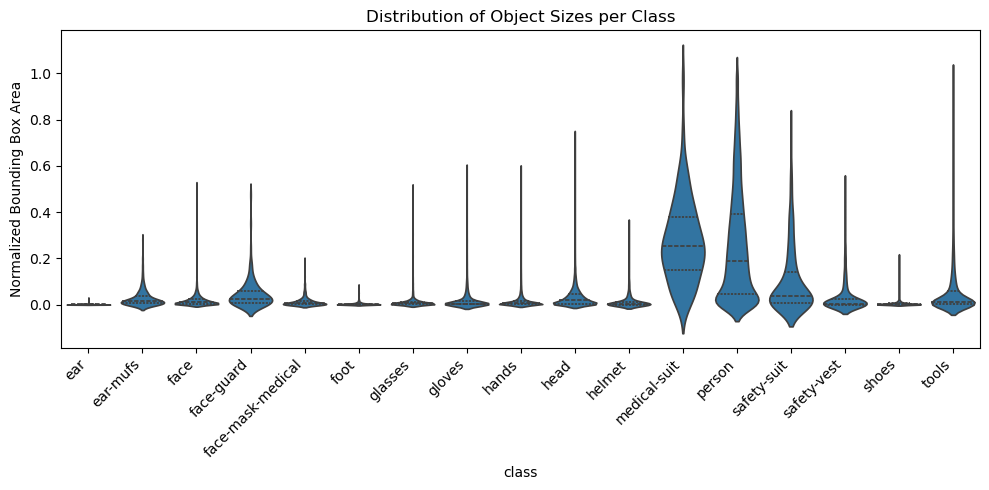

In [19]:
# plot distribution of normalized bounding box areas per class without outliers
plt.figure(figsize=(10, 5))
sns.violinplot(data=df_no_outliers, x="class", y="area_norm", scale="width", inner="quartile")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Normalized Bounding Box Area")
plt.title("Distribution of Object Sizes per Class")
plt.tight_layout()
plt.show()

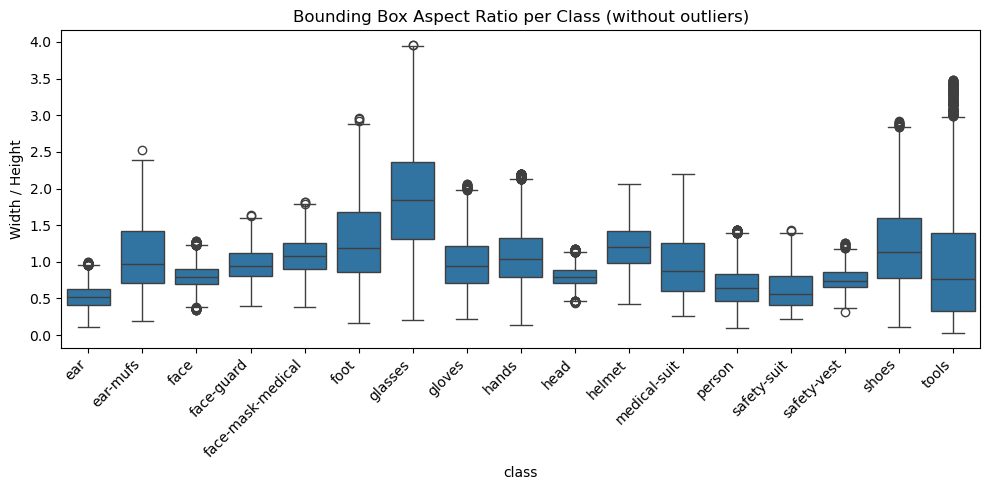

In [20]:
# plot aspect ratio distribution per class without outliers
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_no_outliers, x="class", y="aspect_ratio")
plt.xticks(rotation=45, ha="right")
plt.title("Bounding Box Aspect Ratio per Class (without outliers)")
plt.ylabel("Width / Height")
plt.tight_layout()
plt.show()

### 5. Visualize Bounding Boxes on Image (VOC-BASED)

In [21]:
def show_voc_image_with_boxes():
    xml_file = random.choice(list(VOC_DIR.glob("*.xml")))
    tree = ET.parse(xml_file)
    root = tree.getroot()

    filename = root.find("filename").text
    img = Image.open(IMAGES_DIR / filename)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(img)

    for obj in root.findall("object"):
        name = obj.find("name").text
        bbox = obj.find("bndbox")

        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)

        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        ax.text(xmin, ymin - 3, name, color="red", fontsize=9, weight="bold")

    ax.axis("off")
    plt.show()

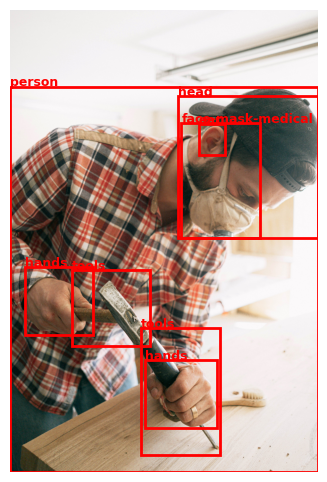

In [24]:
show_voc_image_with_boxes()

### 6. Summary Statistics Table

In [25]:
summary = df.groupby("class").agg(
    instances=("class", "count"),
    images=("image", "nunique"),
    median_area=("area_norm", "median"),
    mean_aspect_ratio=("aspect_ratio", "mean")
).sort_values("instances", ascending=False)

summary

,instances,images,median_area,mean_aspect_ratio
class,,,,
hands,15850,6455,0.006656,1.160249
person,13802,7617,0.195100,0.706698
head,11985,6495,0.018686,0.827427
face,8950,5646,0.011087,0.832843
ear,7730,4884,0.000791,0.552920
tools,4647,2257,0.010087,1.272366
shoes,4560,1570,0.002294,1.273086
gloves,2790,1321,0.004711,1.049242
glasses,1945,1588,0.005252,1.851056
